In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
from pathlib import Path

DICOM_DIR = Path(
    "/content/drive/MyDrive/気合のCOVID19/01_TaskA_CXR/01_前処理/selected_dicom_1277"
)

files = list(DICOM_DIR.glob("*"))

print("DICOMファイル数:", len(files))
print("先頭5件:")
for p in files[:5]:
    print(p.name)

DICOMファイル数: 1277
先頭5件:
A083564.dcm
A085151.dcm
A083074.dcm
A081788.dcm
A081402.dcm


In [5]:
!pip install pydicom

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 40.1 MB/s eta 0:00:00


In [6]:
import pydicom
import pandas as pd

In [7]:
import pydicom
import pandas as pd
from collections import Counter

records = []

for p in files:
    ds = pydicom.dcmread(str(p), stop_before_pixels=True, force=True)

    records.append({
        "PatientID": p.stem,
        "PhotometricInterpretation": getattr(ds, "PhotometricInterpretation", None),
        "BitsAllocated": getattr(ds, "BitsAllocated", None),
        "BitsStored": getattr(ds, "BitsStored", None),
        "HighBit": getattr(ds, "HighBit", None),
        "PixelRepresentation": getattr(ds, "PixelRepresentation", None),
        "Rows": getattr(ds, "Rows", None),
        "Columns": getattr(ds, "Columns", None),
        "RescaleSlope": getattr(ds, "RescaleSlope", None),
        "RescaleIntercept": getattr(ds, "RescaleIntercept", None),
        "WindowCenter": str(getattr(ds, "WindowCenter", None)),
        "WindowWidth": str(getattr(ds, "WindowWidth", None)),
        "Modality": getattr(ds, "Modality", None),
    })

header_df = pd.DataFrame(records)

print("=== 読み込み件数 ===")
print(len(header_df))

for col in [
    "PhotometricInterpretation",
    "BitsAllocated",
    "BitsStored",
    "PixelRepresentation",
    "RescaleSlope",
    "RescaleIntercept",
    "Modality"
]:
    print(f"\n=== {col} ===")
    print(header_df[col].value_counts(dropna=False))

print("\n=== Rows × Columns 上位20 ===")
print(
    header_df.groupby(["Rows", "Columns"])
    .size()
    .sort_values(ascending=False)
    .head(20)
)

print("\n=== WindowCenter 上位20 ===")
print(header_df["WindowCenter"].value_counts(dropna=False).head(20))

print("\n=== WindowWidth 上位20 ===")
print(header_df["WindowWidth"].value_counts(dropna=False).head(20))

=== 読み込み件数 ===
1277

=== PhotometricInterpretation ===
PhotometricInterpretation
MONOCHROME2    1277
Name: count, dtype: int64

=== BitsAllocated ===
BitsAllocated
16    1277
Name: count, dtype: int64

=== BitsStored ===
BitsStored
12    1277
Name: count, dtype: int64

=== PixelRepresentation ===
PixelRepresentation
0    1277
Name: count, dtype: int64

=== RescaleSlope ===
RescaleSlope
1.0    1277
Name: count, dtype: int64

=== RescaleIntercept ===
RescaleIntercept
0.0    1277
Name: count, dtype: int64

=== Modality ===
Modality
CR    1246
DX      31
Name: count, dtype: int64

=== Rows × Columns 上位20 ===
Rows  Columns
2539  3050       367
2517  3028       336
2544  3056       270
2520  3032        28
3050  2539        14
3028  2517        13
3056  2544        11
2510  3028         4
2539  2935         4
2366  3028         3
2539  3043         3
3032  2520         3
2539  3035         3
2517  2956         3
2503  3050         3
2489  3050         3
2215  3028         3
2287  3050       

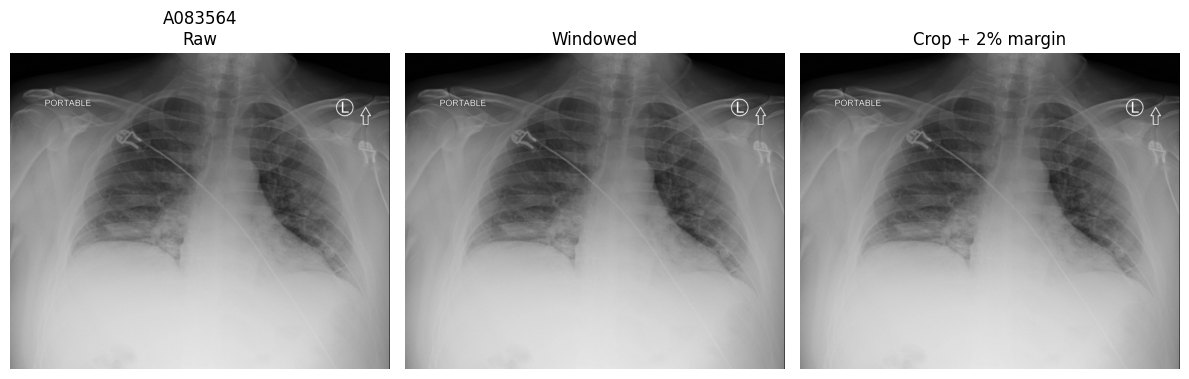

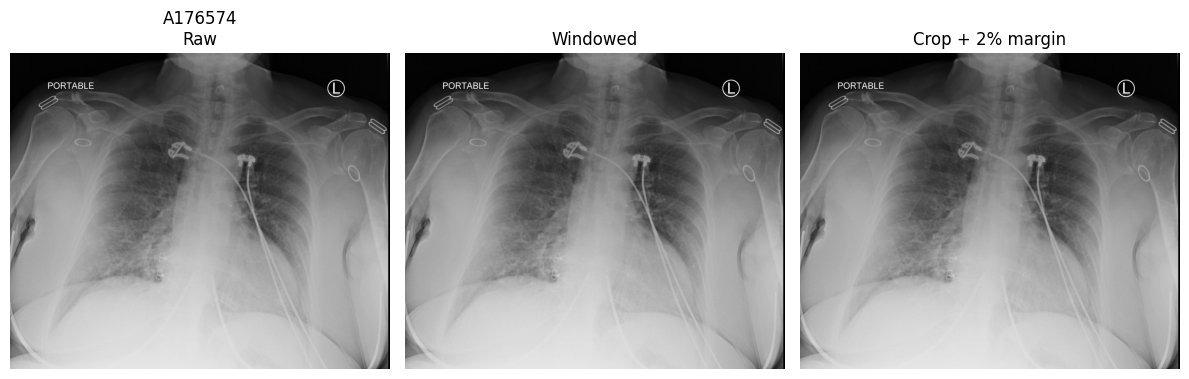

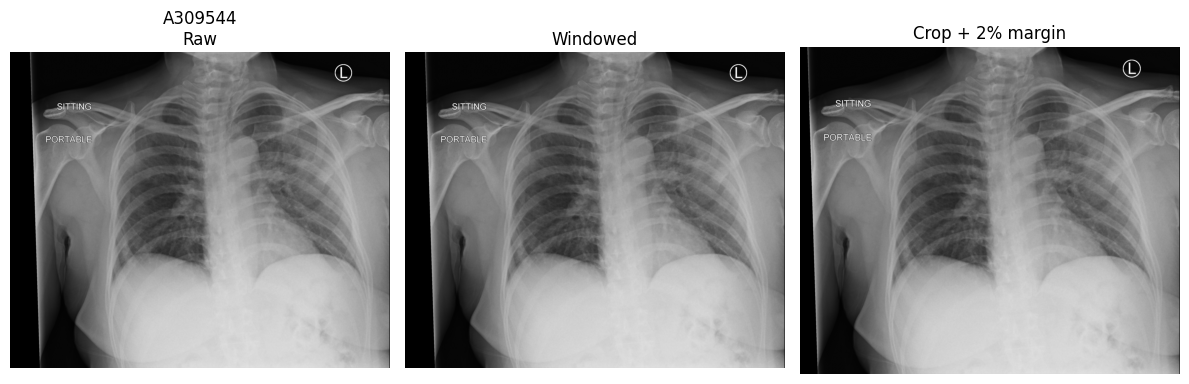

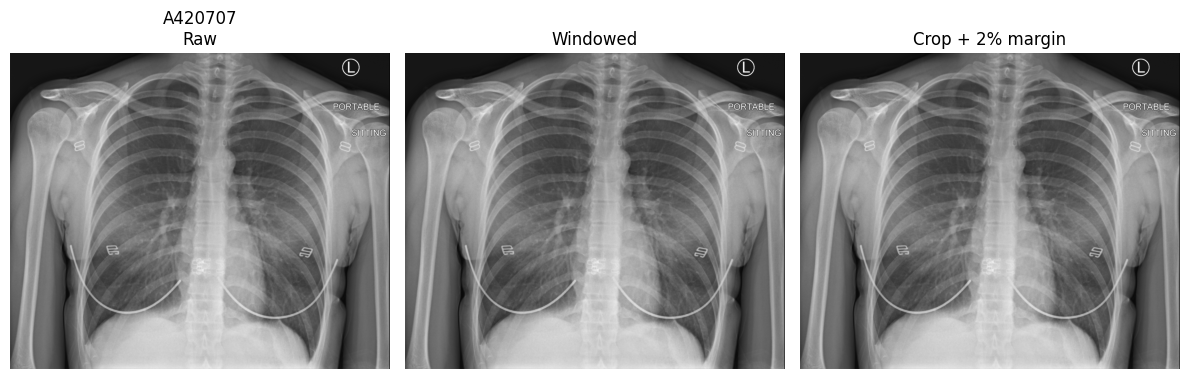

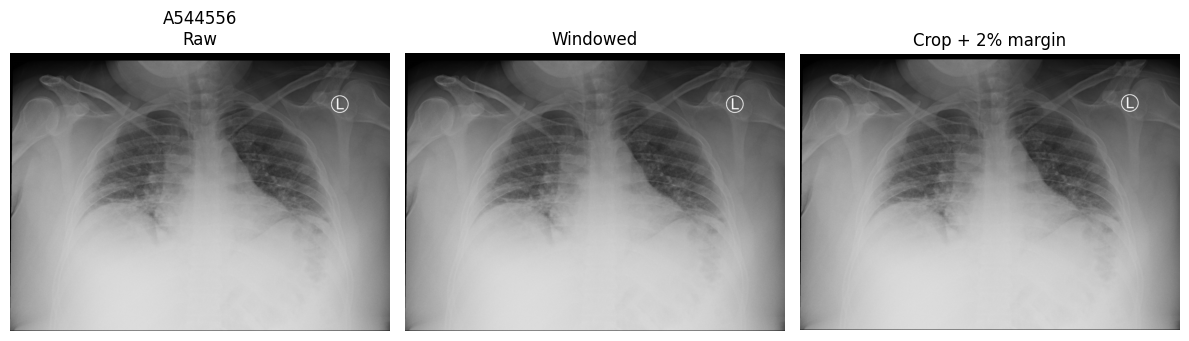

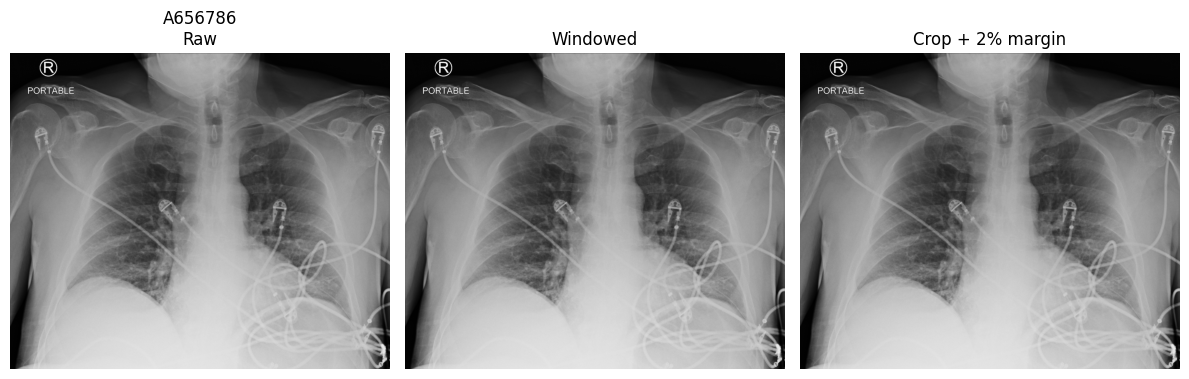

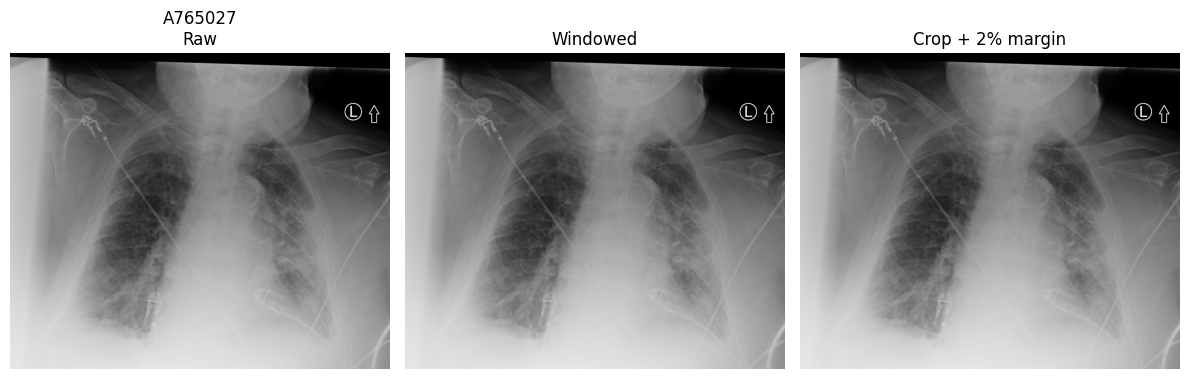

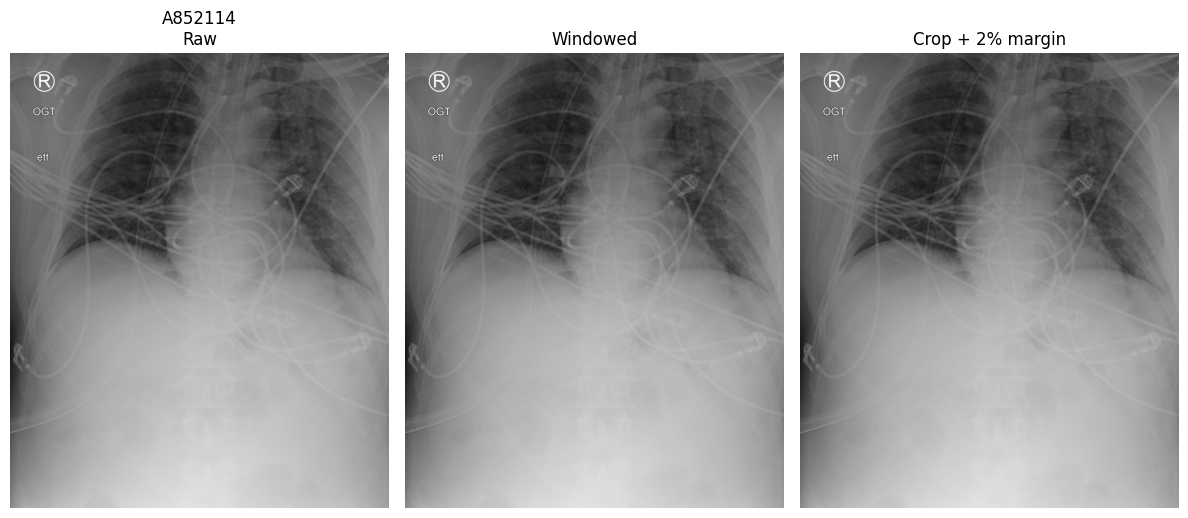

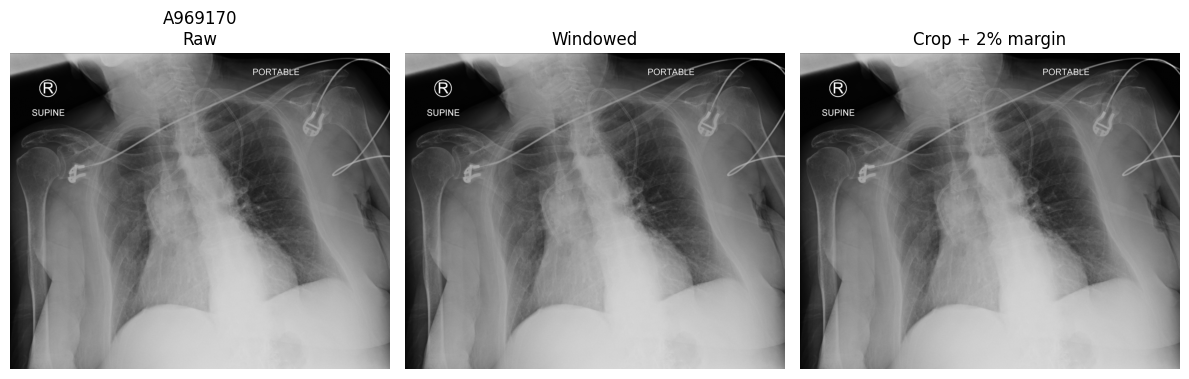

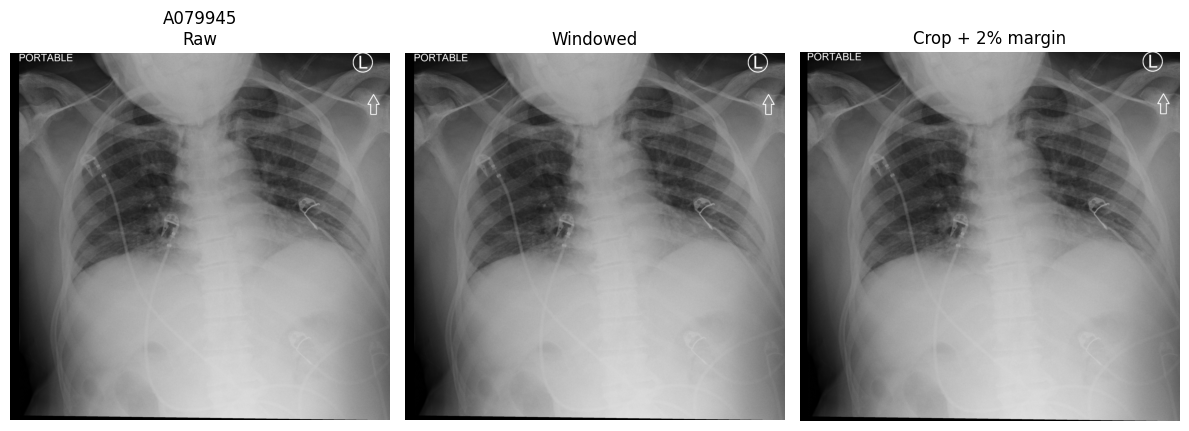

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import pydicom
from pathlib import Path

def apply_window(ds):
    img = ds.pixel_array.astype(np.float32)

    slope = float(getattr(ds, "RescaleSlope", 1.0))
    intercept = float(getattr(ds, "RescaleIntercept", 0.0))
    img = img * slope + intercept

    wc = float(ds.WindowCenter)
    ww = float(ds.WindowWidth)

    low = wc - ww / 2
    high = wc + ww / 2

    img = np.clip(img, low, high)
    img = (img - low) / (high - low)

    return img

def foreground_crop(img, margin_ratio=0.02):
    # 黒背景を除く前景領域を抽出
    mask = img > 0

    if not mask.any():
        return img

    ys, xs = np.where(mask)

    y0, y1 = ys.min(), ys.max()
    x0, x1 = xs.min(), xs.max()

    h, w = img.shape

    margin_y = int((y1 - y0 + 1) * margin_ratio)
    margin_x = int((x1 - x0 + 1) * margin_ratio)

    y0 = max(0, y0 - margin_y)
    y1 = min(h - 1, y1 + margin_y)
    x0 = max(0, x0 - margin_x)
    x1 = min(w - 1, x1 + margin_x)

    return img[y0:y1+1, x0:x1+1]

# 10枚を等間隔で選択
sample_indices = np.linspace(0, len(files) - 1, 10, dtype=int)
sample_files = [files[i] for i in sample_indices]

for p in sample_files:
    ds = pydicom.dcmread(str(p), force=True)

    raw = ds.pixel_array.astype(np.float32)
    windowed = apply_window(ds)
    cropped = foreground_crop(windowed, margin_ratio=0.02)

    fig, axes = plt.subplots(1, 3, figsize=(12, 5))

    axes[0].imshow(raw, cmap="gray")
    axes[0].set_title(f"{p.stem}\nRaw")

    axes[1].imshow(windowed, cmap="gray", vmin=0, vmax=1)
    axes[1].set_title("Windowed")

    axes[2].imshow(cropped, cmap="gray", vmin=0, vmax=1)
    axes[2].set_title("Crop + 2% margin")

    for ax in axes:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import pydicom
import cv2

def apply_window(ds):
    img = ds.pixel_array.astype(np.float32)

    slope = float(getattr(ds, "RescaleSlope", 1.0))
    intercept = float(getattr(ds, "RescaleIntercept", 0.0))
    img = img * slope + intercept

    wc = float(ds.WindowCenter)
    ww = float(ds.WindowWidth)

    low = wc - ww / 2
    high = wc + ww / 2

    img = np.clip(img, low, high)
    img = (img - low) / (high - low)

    return img


def direct_resize(img, size=224):
    return cv2.resize(
        img,
        (size, size),
        interpolation=cv2.INTER_LINEAR
    )


def resize_with_padding(img, size=224):
    h, w = img.shape

    scale = min(size / w, size / h)

    new_w = int(round(w * scale))
    new_h = int(round(h * scale))

    resized = cv2.resize(
        img,
        (new_w, new_h),
        interpolation=cv2.INTER_LINEAR
    )

    canvas = np.zeros((size, size), dtype=np.float32)

    top = (size - new_h) // 2
    left = (size - new_w) // 2

    canvas[top:top + new_h, left:left + new_w] = resized

    return canvas


# 前回と同じように10枚を等間隔で選択
sample_indices = np.linspace(0, len(files) - 1, 10, dtype=int)
sample_files = [files[i] for i in sample_indices]

for p in sample_files:
    ds = pydicom.dcmread(str(p), force=True)

    windowed = apply_window(ds)

    direct = direct_resize(windowed)
    padded = resize_with_padding(windowed)

    fig, axes = plt.subplots(1, 3, figsize=(10, 4))

    axes[0].imshow(windowed, cmap="gray", vmin=0, vmax=1)
    axes[0].set_title(
        f"{p.stem}\nOriginal {windowed.shape[1]}×{windowed.shape[0]}"
    )

    axes[1].imshow(direct, cmap="gray", vmin=0, vmax=1)
    axes[1].set_title("Direct resize\n224×224")

    axes[2].imshow(padded, cmap="gray", vmin=0, vmax=1)
    axes[2].set_title("Aspect ratio + padding\n224×224")

    for ax in axes:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

Output hidden; open in https://colab.research.google.com to view.

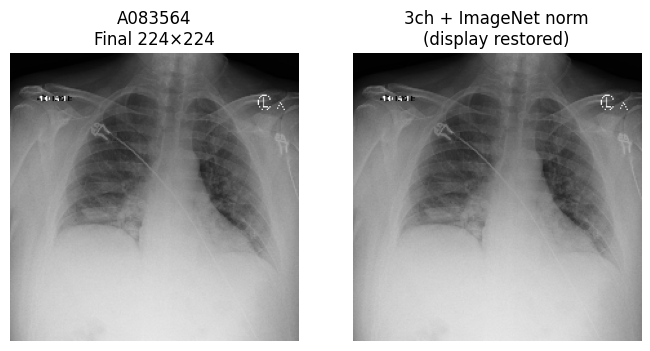

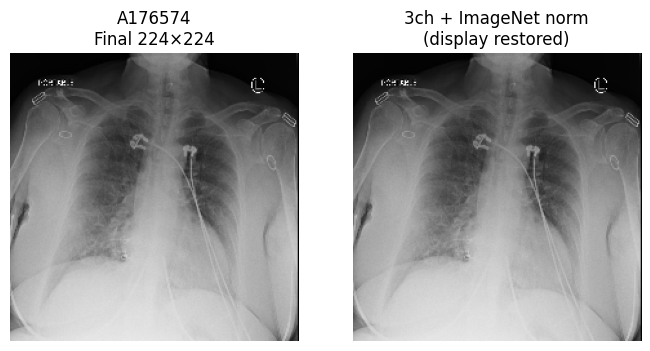

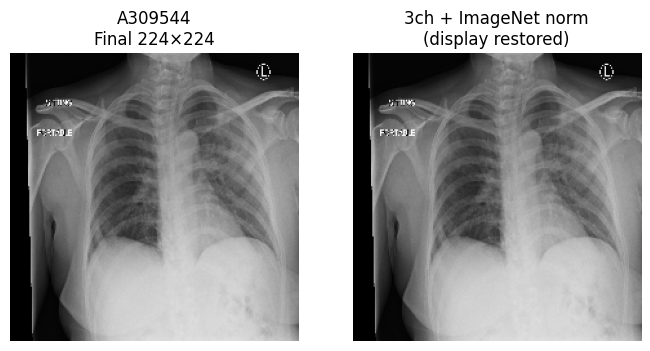

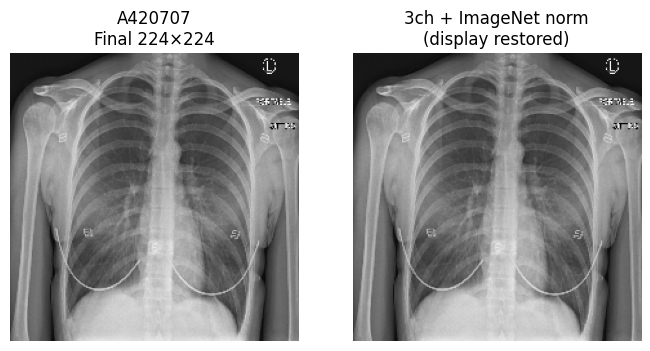

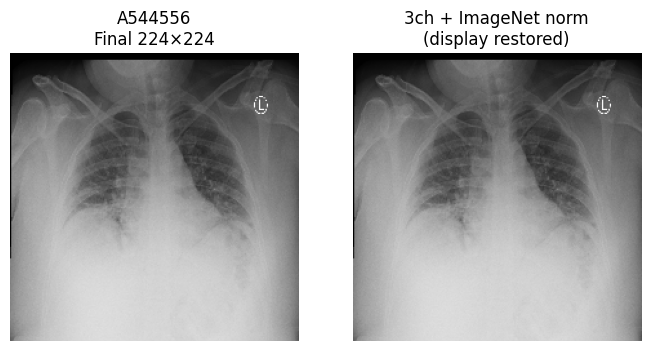

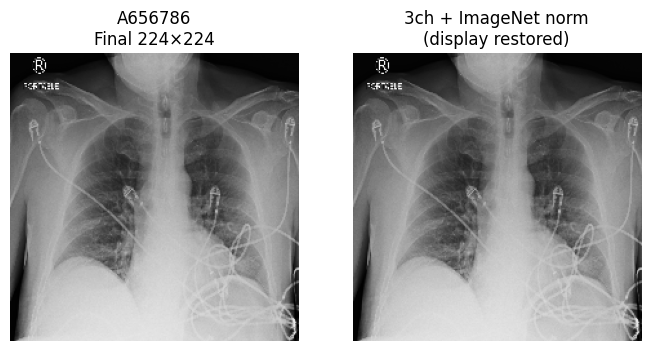

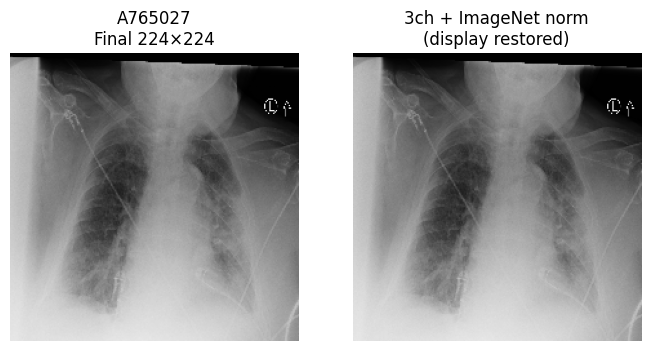

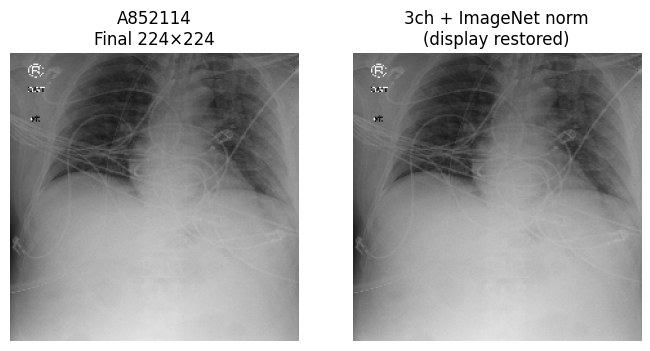

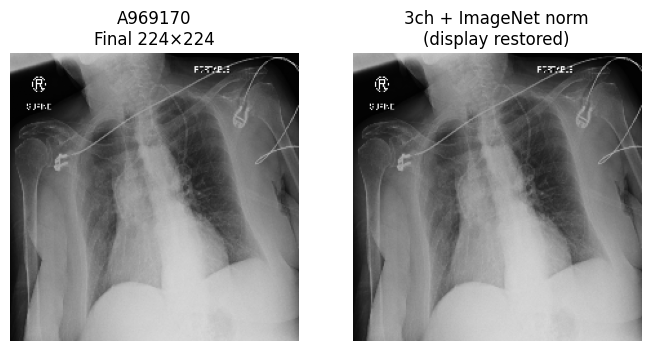

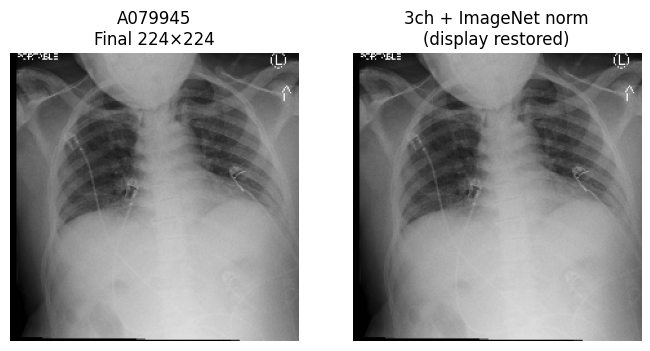

=== 最終出力確認 ===
224×224 shape: (224, 224)
3 channel shape: (224, 224, 3)
normalized shape: (224, 224, 3)
normalized min: -2.117904
normalized max: 2.6295307


In [10]:
import numpy as np
import matplotlib.pyplot as plt
import pydicom
import cv2

# ImageNet normalization
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
IMAGENET_STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32)


def preprocess_cxr(ds):
    # 1. pixel array
    img = ds.pixel_array.astype(np.float32)

    # 2. Rescale Slope / Intercept
    slope = float(getattr(ds, "RescaleSlope", 1.0))
    intercept = float(getattr(ds, "RescaleIntercept", 0.0))
    img = img * slope + intercept

    # 3. MONOCHROME1なら反転
    # 今回の1277枚はすべてMONOCHROME2なので実際には反転されない
    if getattr(ds, "PhotometricInterpretation", "") == "MONOCHROME1":
        img = img.max() - img

    # 4. 固定Windowing
    wc = 2048.0
    ww = 4096.0

    low = wc - ww / 2
    high = wc + ww / 2

    img = np.clip(img, low, high)

    # 5. 0-1 scaling
    img = (img - low) / (high - low)

    # 6. cropなし、224×224へDirect resize
    img224 = cv2.resize(
        img,
        (224, 224),
        interpolation=cv2.INTER_LINEAR
    )

    # 7. grayscale → 3 channel
    img3 = np.stack([img224, img224, img224], axis=-1)

    # 8. ImageNet normalization
    img_norm = (img3 - IMAGENET_MEAN) / IMAGENET_STD

    return img224, img3, img_norm


# 10枚を等間隔で確認
sample_indices = np.linspace(0, len(files) - 1, 10, dtype=int)
sample_files = [files[i] for i in sample_indices]

for p in sample_files:
    ds = pydicom.dcmread(str(p), force=True)

    img224, img3, img_norm = preprocess_cxr(ds)

    fig, axes = plt.subplots(1, 2, figsize=(7, 3.5))

    axes[0].imshow(img224, cmap="gray", vmin=0, vmax=1)
    axes[0].set_title(f"{p.stem}\nFinal 224×224")

    # ImageNet normalization後はそのままだと表示しにくいので、
    # 表示時だけ元の0-1に戻す
    display_img = img_norm * IMAGENET_STD + IMAGENET_MEAN
    display_img = np.clip(display_img, 0, 1)

    axes[1].imshow(display_img)
    axes[1].set_title("3ch + ImageNet norm\n(display restored)")

    for ax in axes:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


print("=== 最終出力確認 ===")
print("224×224 shape:", img224.shape)
print("3 channel shape:", img3.shape)
print("normalized shape:", img_norm.shape)
print("normalized min:", img_norm.min())
print("normalized max:", img_norm.max())

In [11]:
from pathlib import Path
import numpy as np
import pandas as pd
import pydicom
import cv2
from tqdm.auto import tqdm

# 入力
DICOM_DIR = Path(
    "/content/drive/MyDrive/気合のCOVID19/"
    "01_TaskA_CXR/01_前処理/selected_dicom_1277"
)

# 出力
PNG_DIR = Path(
    "/content/drive/MyDrive/気合のCOVID19/"
    "01_TaskA_CXR/01_前処理/processed_png_1277"
)
PNG_DIR.mkdir(parents=True, exist_ok=True)

LOG_PATH = Path(
    "/content/drive/MyDrive/気合のCOVID19/"
    "01_TaskA_CXR/01_前処理/CXR_1277_PNG前処理監査ログ.csv"
)


def dicom_to_png_array(ds):
    # pixel array
    img = ds.pixel_array.astype(np.float32)

    # Rescale
    slope = float(getattr(ds, "RescaleSlope", 1.0))
    intercept = float(getattr(ds, "RescaleIntercept", 0.0))
    img = img * slope + intercept

    # MONOCHROME1なら反転
    # 今回の1277枚は全てMONOCHROME2
    photometric = getattr(ds, "PhotometricInterpretation", "")
    if photometric == "MONOCHROME1":
        img = img.max() - img

    # 固定Windowing
    wc = 2048.0
    ww = 4096.0
    low = wc - ww / 2
    high = wc + ww / 2

    img = np.clip(img, low, high)

    # 0–1 scaling
    img = (img - low) / (high - low)

    # cropなし
    # 224×224 Direct resize
    img = cv2.resize(
        img,
        (224, 224),
        interpolation=cv2.INTER_LINEAR
    )

    # PNG保存用に0–255 uint8へ変換
    img_uint8 = np.round(img * 255).astype(np.uint8)

    return img_uint8


files = sorted(DICOM_DIR.glob("*.dcm"))

print("DICOM件数:", len(files))

records = []

for p in tqdm(files):

    try:
        ds = pydicom.dcmread(str(p), force=True)

        img_png = dicom_to_png_array(ds)

        output_path = PNG_DIR / f"{p.stem}.png"

        success = cv2.imwrite(
            str(output_path),
            img_png
        )

        records.append({
            "PatientID": p.stem,
            "dicom_file": p.name,
            "png_file": output_path.name,
            "height": img_png.shape[0],
            "width": img_png.shape[1],
            "dtype": str(img_png.dtype),
            "min_pixel": int(img_png.min()),
            "max_pixel": int(img_png.max()),
            "save_success": bool(success),
            "error": ""
        })

    except Exception as e:

        records.append({
            "PatientID": p.stem,
            "dicom_file": p.name,
            "png_file": "",
            "height": np.nan,
            "width": np.nan,
            "dtype": "",
            "min_pixel": np.nan,
            "max_pixel": np.nan,
            "save_success": False,
            "error": str(e)
        })


log_df = pd.DataFrame(records)

log_df.to_csv(
    LOG_PATH,
    index=False,
    encoding="utf-8-sig"
)

print("\n=== 前処理結果 ===")
print("入力DICOM:", len(files))
print("PNG保存成功:", log_df["save_success"].sum())
print("PNG保存失敗:", (~log_df["save_success"]).sum())
print("出力PNG実数:", len(list(PNG_DIR.glob("*.png"))))

print("\n=== サイズ確認 ===")
print(
    log_df.groupby(["height", "width"])
    .size()
    .sort_values(ascending=False)
    .head()
)

print("\n=== エラー ===")
print(log_df.loc[~log_df["save_success"], ["PatientID", "error"]])

print("\n監査ログ保存先:")
print(LOG_PATH)

DICOM件数: 1277


  0%|          | 0/1277 [00:00<?, ?it/s]


=== 前処理結果 ===
入力DICOM: 1277
PNG保存成功: 1277
PNG保存失敗: 0
出力PNG実数: 1277

=== サイズ確認 ===
height  width
224     224      1277
dtype: int64

=== エラー ===
Empty DataFrame
Columns: [PatientID, error]
Index: []

監査ログ保存先:
/content/drive/MyDrive/気合のCOVID19/01_TaskA_CXR/01_前処理/CXR_1277_PNG前処理監査ログ.csv
